<a href="https://colab.research.google.com/github/adanzee/Encoder-Decoder-model-prac/blob/main/Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing libraries**


In [ ]:


# ── 1. Import Libraries ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.datasets import mnist

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")

TensorFlow version: 2.19.0
NumPy version:      2.0.2


**Load** **Dataset**

In [ ]:

(x_train, _), (x_test, _) = mnist.load_data()

print(f"Train shape before preprocessing: {x_train.shape}")
print(f"Test  shape before preprocessing: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape before preprocessing: (60000, 28, 28)
Test  shape before preprocessing: (10000, 28, 28)


**Preprocess Data**

In [ ]:

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Flatten 28×28 images → 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print(f"Train shape after  preprocessing: {x_train.shape}")
print(f"Test  shape after  preprocessing: {x_test.shape}")

Train shape after  preprocessing: (60000, 784)
Test  shape after  preprocessing: (10000, 784)


**Build Encoder**

In [ ]:

# Reduces 784 → 128 → 64 → 32 (latent space)
encoder_input = layers.Input(shape=(784,), name="encoder_input")
x = layers.Dense(128, activation="relu", name="enc_dense_1")(encoder_input)
x = layers.Dense(64,  activation="relu", name="enc_dense_2")(x)
latent = layers.Dense(32, activation="relu", name="latent_space")(x)

encoder = Model(encoder_input, latent, name="Encoder")
encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

**Build** **Decoder**

In [ ]:

# Reconstructs 32 → 64 → 128 → 784
decoder_input = layers.Input(shape=(32,), name="decoder_input")
x = layers.Dense(64,  activation="relu",    name="dec_dense_1")(decoder_input)
x = layers.Dense(128, activation="relu",    name="dec_dense_2")(x)
decoder_output = layers.Dense(784, activation="sigmoid", name="decoder_output")(x)

decoder = Model(decoder_input, decoder_output, name="Decoder")
decoder.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

**conbine**

In [ ]:

autoencoder_input = layers.Input(shape=(784,), name="autoencoder_input")
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded, name="Autoencoder")
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [ ]:

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",   # suitable for pixel values in [0, 1]
    metrics=["mse"]
)

**Training **

In [ ]:

EPOCHS     = 20
BATCH_SIZE = 256

history = autoencoder.fit(
    x_train, x_train,          # input = target (reconstruction task)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2512 - mse: 0.0630 - val_loss: 0.1712 - val_mse: 0.0366
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1544 - mse: 0.0307 - val_loss: 0.1424 - val_mse: 0.0267
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1365 - mse: 0.0246 - val_loss: 0.1279 - val_mse: 0.0218
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1244 - mse: 0.0205 - val_loss: 0.1181 - val_mse: 0.0185
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1165 - mse: 0.0179 - val_loss: 0.1128 - val_mse: 0.0167
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1120 - mse: 0.0164 - val_loss: 0.1093 - val_mse: 0.0156
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1093 - mse: 0.0155 - val_loss: 0.1071 - val_mse: 0.0149
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1071 - mse: 0.0148 - val_loss: 0.1046 - val_mse: 0.0141
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - l

**Visualization**

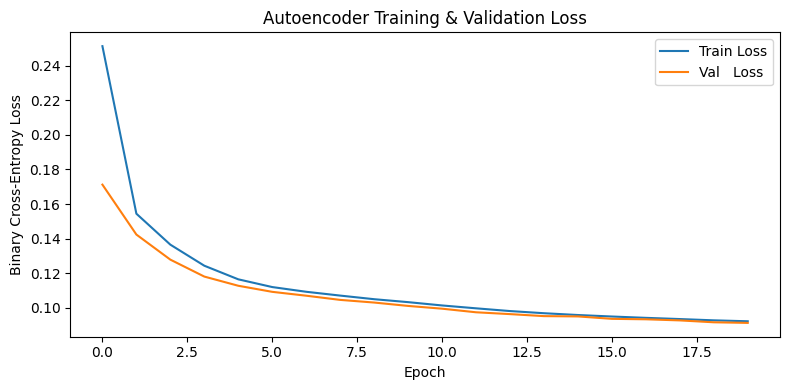

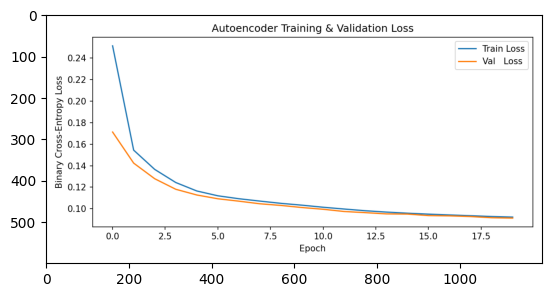

Saved: training_loss.png


In [ ]:
from PIL import Image
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val   Loss")
plt.title("Autoencoder Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

print("Saved: training_loss.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


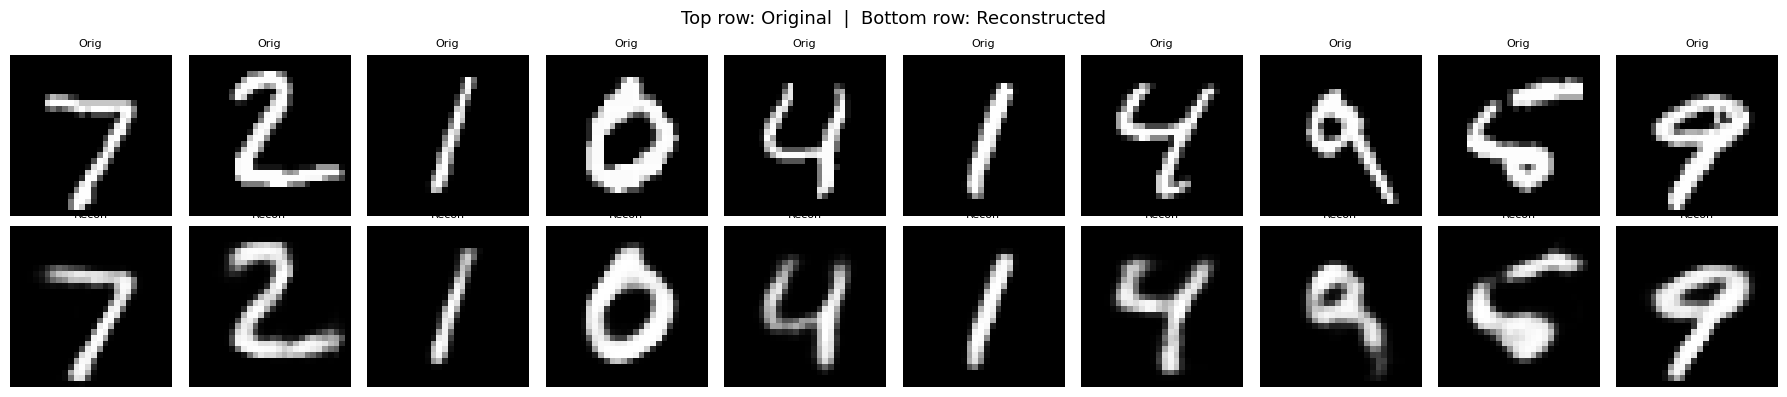

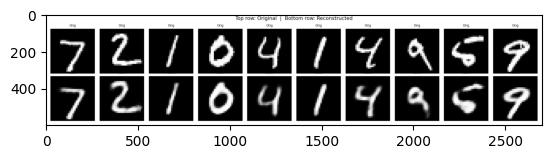

Saved: reconstruction.png


In [ ]:

n_samples = 10                               # number of images to display
reconstructed = autoencoder.predict(x_test[:n_samples])

fig, axes = plt.subplots(2, n_samples, figsize=(18, 4))
fig.suptitle("Top row: Original  |  Bottom row: Reconstructed", fontsize=13)

for i in range(n_samples):
    # Original
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Orig", fontsize=8)

    # Reconstructed
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon", fontsize=8)

plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150)
plt.show()
plt.imshow(Image.open("reconstruction.png"))
plt.show()
print("Saved: reconstruction.png")

**Test Set**

In [ ]:

test_loss, test_mse = autoencoder.evaluate(x_test, x_test, verbose=0)
print(f"\nTest Loss (Binary Cross-Entropy) : {test_loss:.4f}")
print(f"Test MSE                          : {test_mse:.4f}")


Test Loss (Binary Cross-Entropy) : 0.0913
Test MSE                          : 0.0098


**Adding PCA to reduce dimensions**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


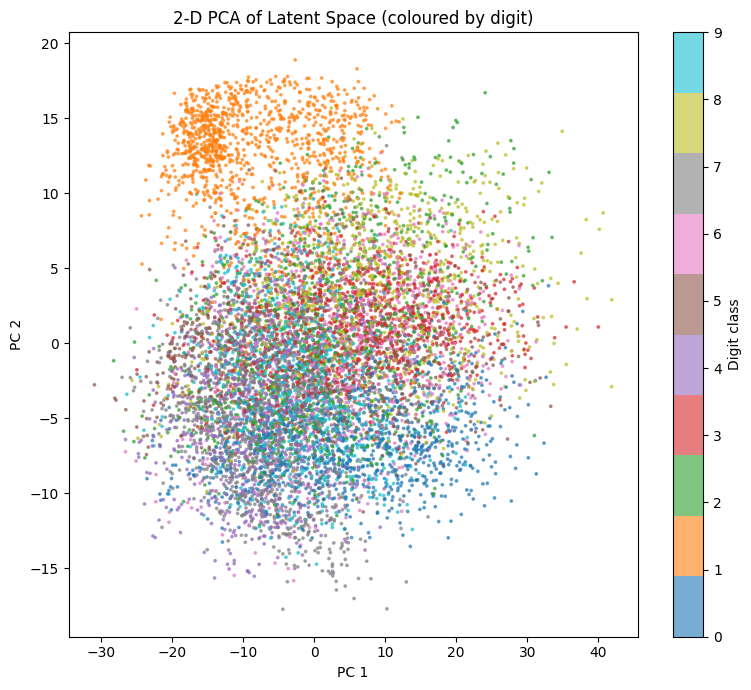

Saved: latent_space_pca.png


In [ ]:

from sklearn.decomposition import PCA

latent_vectors = encoder.predict(x_test)          # shape (10000, 32)
_, (_, y_test) = mnist.load_data()                # reload labels for colouring

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=y_test, cmap="tab10", s=3, alpha=0.6
)
plt.colorbar(scatter, label="Digit class")
plt.title("2-D PCA of Latent Space (coloured by digit)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.savefig("latent_space_pca.png", dpi=150)
plt.show()
print("Saved: latent_space_pca.png")